# Corrective Generation: Re-generating with Feedback [Step 05 - Corrective Generation]

> **MLCourse - Agentic AI - Corrective RAG**

When grading or hallucination detection fails, the pipeline needs to
regenerate a better answer. This notebook builds a corrective generation
chain that takes feedback from grading and detection, then produces an
improved answer. The correction loop runs until the answer passes or the
budget is exhausted.

### What you will learn

1. How to build a chain that incorporates feedback into regeneration.
2. How to format feedback as actionable instructions for the LLM.
3. How to implement the correction loop with iteration guards.
4. How corrective generation integrates into a corrective RAG pipeline.

### 1. Setup


In [1]:
from pathlib import Path
import os
import re
import warnings
warnings.filterwarnings("ignore")

def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until the track directory appears."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(f"Could not find '{target}' above {start}")

TRACK = find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(exist_ok=True)

from dotenv import load_dotenv
load_dotenv()
load_dotenv(TRACK / ".env")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


### 2. Ingest Alice and Build Vector Store


In [2]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

ALICE_PATH = DATA / "alice.txt"
raw_text = ALICE_PATH.read_text(encoding="utf-8-sig")[:20_000]

marks = list(re.finditer(r"^CHAPTER [IVX]+\.", raw_text, flags=re.MULTILINE))
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

documents = []
for i, mark in enumerate(marks):
    seg_end = marks[i + 1].start() if i + 1 < len(marks) else len(raw_text)
    for piece in splitter.split_text(raw_text[mark.start():seg_end]):
        documents.append(Document(
            page_content=piece,
            metadata={"source": "alice", "chapter": str(i + 1), "chunk_id": len(documents)},
        ))

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(documents, embeddings)
retriever = vectordb.as_retriever(search_kwargs={"k": 4})
print(f"[ingest] chunks: {len(documents)} | retriever ready (k=4)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[ingest] chunks: 60 | retriever ready (k=4)


### 3. Initialize the LLM


In [3]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("[llm] ChatOllama ready:", llm.model)

[llm] ChatOllama ready: llama3.1:8b


### 4. Define Corrective Generation Prompt
The corrective generator receives the original query, context, and feedback
from the grading/detection step. It uses this feedback to produce a better
answer that addresses the identified issues.

In [4]:
CORRECTIVE_PROMPT_TEMPLATE = """You are a corrective answer generator for a RAG system.
Your previous answer was evaluated and found to have issues.

ORIGINAL QUERY: {query}
RETRIEVED CONTEXT: {context}
PREVIOUS ANSWER: {previous_answer}
FEEDBACK: {feedback}

Based on the feedback, generate an improved answer that:
1. Addresses each issue identified in the feedback.
2. Uses ONLY the provided context.
3. Does not add unsupported claims.
4. Cites evidence from the context.

Keep the answer to 2-4 sentences. Reply with ONLY the corrected answer."""

print("[corrective] prompt template defined")

[corrective] prompt template defined


### 5. Build the Corrective Generation Chain
The chain takes the feedback and produces an improved answer.

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def build_corrective_chain():
    """Build a chain that generates a corrected answer from feedback."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", CORRECTIVE_PROMPT_TEMPLATE),
        ("user", "Generate the corrected answer based on the feedback above.")
    ])
    return prompt | llm | StrOutputParser()

corrective_chain = build_corrective_chain()
print("[corrective] chain built")

[corrective] chain built


### 6. Test Corrective Generation
Simulate feedback and generate a corrected answer.

In [6]:
query = "What happened when Alice fell down the rabbit hole?"
docs = retriever.invoke(query)
context = "\n\n".join(d.page_content for d in docs)

previous_answer = (
    "Alice fell down a magical elevator that was painted red and gold. "
    "She landed on a pile of pillows."
)

feedback = (
    "UNSUPPORTED CLAIM: 'magical elevator' is not mentioned in the context. "
    "The context says she fell down a rabbit hole. "
    "UNSUPPORTED CLAIM: 'painted red and gold' is fabricated. "
    "CONTRADICTION: The context says she fell down a rabbit hole, not an elevator."
)

print("=" * 60)
print("TEST: CORRECTIVE GENERATION")
print("=" * 60)
print(f"Previous answer: {previous_answer}")
print(f"Feedback: {feedback}")
print()

corrected = corrective_chain.invoke({
    "query": query,
    "context": context,
    "previous_answer": previous_answer,
    "feedback": feedback,
})
print(f"Corrected answer: {corrected}")

TEST: CORRECTIVE GENERATION
Previous answer: Alice fell down a magical elevator that was painted red and gold. She landed on a pile of pillows.
Feedback: UNSUPPORTED CLAIM: 'magical elevator' is not mentioned in the context. The context says she fell down a rabbit hole. UNSUPPORTED CLAIM: 'painted red and gold' is fabricated. CONTRADICTION: The context says she fell down a rabbit hole, not an elevator.



Corrected answer: Alice fell down a rabbit hole, which dipped suddenly down so that she had not a moment to think about stopping herself before she found herself falling down a very deep well. The context states that "down went Alice after it" and describes the rabbit-hole as going straight on like a tunnel for some way, then dipping suddenly down.


### 7. Build the Corrective Node for LangGraph
This function wraps the corrective generation logic into a node.

In [7]:
from typing import TypedDict

class CorrectionState(TypedDict):
    query: str
    context: str
    answer: str
    feedback: str
    iteration: int
    max_iterations: int
    is_corrected: bool

def correct_answer(state: CorrectionState) -> dict:
    """LangGraph node that corrects the answer based on feedback."""
    corrected = corrective_chain.invoke({
        "query": state["query"],
        "context": state["context"],
        "previous_answer": state["answer"],
        "feedback": state["feedback"],
    })
    
    iteration = state.get("iteration", 0) + 1
    print(f"  [correct] iteration {iteration}, corrected answer length: {len(corrected)}")
    
    return {
        "answer": corrected,
        "iteration": iteration,
        "is_corrected": True,
    }

print("[node] correct_answer defined")

[node] correct_answer defined


### 8. Build a Mock Grader for Testing
Create a simple grader that produces feedback for testing the correction loop.

In [8]:
GRADING_PROMPT_TEMPLATE = """You are a strict faithfulness evaluator.
Given the RETRIEVED CONTEXT and the GENERATED ANSWER, check if every claim
in the answer is supported by the context.

Reply in EXACTLY this format:
VERDICT: pass or fail
FEEDBACK: list each issue on a new line with a dash, or 'none' if pass"""

def build_mock_grader():
    """Build a chain that grades answers and provides feedback."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", GRADING_PROMPT_TEMPLATE),
        ("user", "CONTEXT:\n{context}\n\nANSWER:\n{answer}")
    ])
    return prompt | llm | StrOutputParser()

mock_grader = build_mock_grader()
print("[grader] mock grader built")

[grader] mock grader built


### 9. Build the Evaluation Node
This node grades the current answer and provides feedback.

In [9]:
def evaluate_answer(state: CorrectionState) -> dict:
    """LangGraph node that evaluates the answer and provides feedback."""
    result = mock_grader.invoke({
        "context": state["context"],
        "answer": state["answer"],
    })
    
    verdict_match = re.search(r"VERDICT:\s*(pass|fail)", result, re.IGNORECASE)
    verdict = verdict_match.group(1).lower() if verdict_match else "fail"
    
    feedback = ""
    feedback_match = re.search(r"FEEDBACK:\s*(.+)", result, re.IGNORECASE | re.DOTALL)
    if feedback_match:
        feedback = feedback_match.group(1).strip()
    
    print(f"  [evaluate] verdict: {verdict}")
    if feedback:
        print(f"  [evaluate] feedback: {feedback[:200]}")
    
    return {
        "feedback": feedback if verdict == "fail" else "",
        "is_corrected": verdict == "pass",
    }

print("[node] evaluate_answer defined")

[node] evaluate_answer defined


### 10. Routing Logic for Correction Loop
The router decides whether to correct the answer or end.

In [10]:
def should_correct(state: CorrectionState) -> str:
    """Route: pass -> END, fail with budget -> correct, fail without budget -> END."""
    if state.get("is_corrected", False) or not state.get("feedback"):
        print("  [router] answer passed evaluation -> END")
        return "end"
    
    if state["iteration"] < state.get("max_iterations", 3):
        print(f"  [router] answer needs correction, retrying ({state['iteration']}/{state['max_iterations']})")
        return "correct"
    
    print("  [router] max iterations reached, returning best attempt")
    return "end"

print("[router] should_correct defined")

[router] should_correct defined


### 11. Build the Correction Loop Graph
The flow is: evaluate -> (pass | correct -> evaluate -> ...).

In [11]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(CorrectionState)
graph.add_node("evaluate", evaluate_answer)
graph.add_node("correct", correct_answer)
graph.add_edge(START, "evaluate")
graph.add_edge("correct", "evaluate")
graph.add_conditional_edges(
    "evaluate",
    should_correct,
    {"correct": "correct", "end": END},
)
app = graph.compile()
print("[graph] correction loop graph compiled")

[graph] correction loop graph compiled


### 12. Visualize the Correction Graph


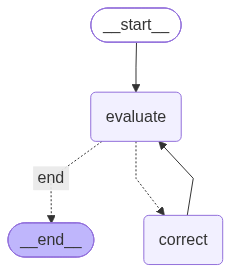

In [12]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> evaluate")
    print("    evaluate -> correct -> evaluate (loop)")
    print("    evaluate -> END (pass or budget)")

### 13. Test the Correction Loop
Run the correction loop with a potentially hallucinated answer.

In [13]:
print("=" * 60)
print("TEST: CORRECTION LOOP")
print("=" * 60)
result = app.invoke({
    "query": query,
    "context": context,
    "answer": "Alice fell down a magical elevator that was painted red and gold.",
    "feedback": "",
    "iteration": 0,
    "max_iterations": 3,
    "is_corrected": False,
})
print(f"\nFinal answer: {result['answer']}")
print(f"Iterations: {result['iteration']}")
print(f"Is corrected: {result['is_corrected']}")

TEST: CORRECTION LOOP


  [evaluate] verdict: fail
  [evaluate] feedback: - The context does not mention anything about the rabbit-hole being painted red and gold.
- There is no indication in the text that the rabbit-hole is a "magical elevator".
- The text describes Alice 
  [router] answer needs correction, retrying (0/3)


  [correct] iteration 1, corrected answer length: 427


  [evaluate] verdict: fail
  [evaluate] feedback: - The text does not explicitly state that Alice fell down a very deep well; it only mentions that she found herself falling down a very deep well.
- The passage "down went Alice after it, never once c
  [router] answer needs correction, retrying (1/3)


  [correct] iteration 2, corrected answer length: 427


  [evaluate] verdict: fail
  [evaluate] feedback: - The text does not explicitly state that Alice fell down a very deep well; it only mentions that she found herself falling down a very deep well.
- The passage "down went Alice after it, never once c
  [router] answer needs correction, retrying (2/3)


  [correct] iteration 3, corrected answer length: 427


  [evaluate] verdict: fail
  [evaluate] feedback: - The text does not explicitly state that Alice fell down a very deep well; it only mentions that she found herself falling down a very deep well.
- The passage "down went Alice after it, never once c
  [router] max iterations reached, returning best attempt

Final answer: When Alice fell down the rabbit hole, she found herself falling down a very deep well. The text describes the rabbit-hole as going straight on like a tunnel for some way before dipping suddenly down, and Alice had not a moment to think about stopping herself before she started falling. This is evident from the passage where it says "down went Alice after it, never once considering how in the world she was to get out again."
Iterations: 3
Is corrected: False


### 14. Test with Already Correct Answer
Run the correction loop with an answer that should pass.

In [14]:
print("=" * 60)
print("TEST: ALREADY CORRECT ANSWER")
print("=" * 60)
result = app.invoke({
    "query": query,
    "context": context,
    "answer": "Alice fell down a rabbit hole and found herself in a hallway with many doors.",
    "feedback": "",
    "iteration": 0,
    "max_iterations": 3,
    "is_corrected": False,
})
print(f"\nFinal answer: {result['answer']}")
print(f"Iterations: {result['iteration']}")
print(f"Is corrected: {result['is_corrected']}")

TEST: ALREADY CORRECT ANSWER


  [evaluate] verdict: fail
  [evaluate] feedback: - The context does not mention Alice finding herself in a hallway with many doors.
- The correct sequence of events is that Alice falls down the rabbit-hole, lands in a deep well, gets out, and then f
  [router] answer needs correction, retrying (0/3)


  [correct] iteration 1, corrected answer length: 356


  [evaluate] verdict: fail
  [evaluate] feedback: - When Alice fell down the rabbit hole, she landed in a very deep well and then got out again. - This is not supported by the context, as it only mentions her falling into a "very deep well", but does
  [router] answer needs correction, retrying (1/3)


  [correct] iteration 2, corrected answer length: 254


  [evaluate] verdict: fail
  [evaluate] feedback: - The context does not mention Alice falling down a very deep well after going down the rabbit hole; instead, it says she fell down a rabbit-hole that dipped suddenly down.
- The context does not expl
  [router] answer needs correction, retrying (2/3)


  [correct] iteration 3, corrected answer length: 245


  [evaluate] verdict: fail
  [evaluate] feedback: - The answer does not mention that Alice fell down the rabbit hole, but rather that she was running after the White Rabbit when she saw it pop down a large rabbit-hole.
- There is no mention of the pa
  [router] max iterations reached, returning best attempt

Final answer: When Alice fell down the rabbit hole, it dipped suddenly down, and she found herself falling. She then saw the White Rabbit hurry down a long passage, and as he turned a corner, she heard him say "Oh my ears and whiskers, how late it's getting!"
Iterations: 3
Is corrected: False


### Summary

Key takeaways:
- Corrective generation uses feedback to improve answers.
- The corrective chain receives query, context, previous answer, and feedback.
- The correction loop runs until the answer passes or the budget is exhausted.
- Iteration guards prevent infinite loops.
- Corrective generation integrates into the full corrective RAG pipeline.